In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df=pd.read_excel('~/Desktop/DATA_clinical/Clinical_fm_66.xlsx',sheet_name='data_66')
cols = {
    'rid':           'subject_id',
    'gp':            'group',
    '1_age':         'age',
    '1_vas_pain_iv': 'vas_pain',
    '6_hamd_total':  'hamd_total',
    '6_hamd_cat':    'hamd_cat',
    '7_hama_total':  'hama_total',
    '11_ts':         'tas_total',
    '11_ id':         'tas_dif',
    '11_df':         'tas_ddf',
    '11_eot':        'tas_eot',
    '11_cat':        'alexithymia',
    '10_R':          'erq_reappraisal',
    '10_S':          'erq_suppression'
}

In [4]:
print(df.head(5))
print(df.columns.tolist())

   rid  gp  1_age  1_sch_deg  1_yr_study  1_marital_st  1_occ  1_occ_t  \
0    2   0     50          1         6.0             2      5        0   
1    4   0     43          6        22.0             2      6        1   
2    5   0     40          3        16.0             3      5        0   
3    6   0     42          6        19.0             2      5        0   
4    7   1     43          6        25.0             2      1        1   

   1_m_inc  1_inc_dep  ...  15_6  15_7  15_8  16_int_task_ti  16_w  16_h  \
0     4000        1.0  ...  14.0  80.0  93.0            17.0  50.0   142   
1    13000        1.0  ...  28.0  71.0  99.0            15.0  68.0   156   
2     7000        1.0  ...   NaN   NaN   NaN             NaN  64.0   164   
3    30000        1.0  ...  35.0  98.0  99.0             4.0  82.0   165   
4    43000        1.0  ...  37.0  22.0  38.0             3.0  56.0   164   

   16_bmi  16_mri_h  16_comorb_p  16_comorb  
0    24.8      12.0            1        1.0  
1    2

In [5]:
df_clean = df[list(cols.keys())].rename(columns=cols)
df_clean = df[list(cols.keys())].rename(columns=cols)
print(df_clean['group'].unique())

[0 1]


In [6]:
print(df_clean.head(5))
print(df_clean['group'].unique())


   subject_id  group  age  vas_pain  hamd_total  hamd_cat  hama_total  \
0           2      0   50        73          17         2          29   
1           4      0   43        59          14         2          20   
2           5      0   40        69          19         3          28   
3           6      0   42        56          21         3          21   
4           7      1   43         0           0         0           0   

   tas_total  tas_dif  tas_ddf  tas_eot  alexithymia  erq_reappraisal  \
0         94       38       21       35            3               31   
1         50       21       17       12            1               29   
2         71       32       14       25            3               28   
3         93       35       20       38            3               42   
4         44       22        9       13            1               32   

   erq_suppression  
0               20  
1               14  
2                4  
3               24  
4               1

In [7]:
print(df_clean.shape)
col_names=df_clean.columns.tolist()
print(col_names)
print(df_clean['group'].unique())
print(df_clean['group'].dtype)
df_clean['group'] = df_clean['group'].map({0: 'FM', 1: 'HC'})
graph_cols = ['age', 'vas_pain', 'hamd_total', 'hama_total', 'tas_total', 
'tas_dif', 'tas_ddf', 'tas_eot', 'erq_reappraisal', 'erq_suppression']
print(graph_cols)
print(len(graph_cols))


(66, 14)
['subject_id', 'group', 'age', 'vas_pain', 'hamd_total', 'hamd_cat', 'hama_total', 'tas_total', 'tas_dif', 'tas_ddf', 'tas_eot', 'alexithymia', 'erq_reappraisal', 'erq_suppression']
[0 1]
int64
['age', 'vas_pain', 'hamd_total', 'hama_total', 'tas_total', 'tas_dif', 'tas_ddf', 'tas_eot', 'erq_reappraisal', 'erq_suppression']
10


In [8]:
%matplotlib inline
print(df_clean['group'].unique())



<StringArray>
['FM', 'HC']
Length: 2, dtype: str


In [9]:
print(df_clean['group'].unique())
print(df_clean['group'].dtype)

<StringArray>
['FM', 'HC']
Length: 2, dtype: str
str


In [10]:
print(df['gp'].unique())
print(df['gp'].dtype)

[0 1]
int64


In [11]:
print(df_clean['group'].value_counts())


group
FM    33
HC    33
Name: count, dtype: int64


In [12]:
print(df_clean.shape)
print(df_clean['group'].value_counts())
print(df_clean['age'].head())

(66, 14)
group
FM    33
HC    33
Name: count, dtype: int64
0    50
1    43
2    40
3    42
4    43
Name: age, dtype: int64


In [13]:
#this is Mann-Whitney and p value

from scipy import stats

p_values = {}
for var in graph_cols:
    fm_vals = df_clean[df_clean['group'] == 'FM'][var].dropna()
    hc_vals = df_clean[df_clean['group'] == 'HC'][var].dropna()
    _, p = stats.mannwhitneyu(fm_vals, hc_vals, alternative='two-sided')
    p_values[var] = p

/var/folders/bm/fm81vfpd7_db09ct9qj8qj1xfjtj07/T/ipykernel_59368/3101768000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean,x='group',y=graph_cols[k],palette={'FM': "#F9A0EC", 'HC': "#8EA0D9"},ax=ax)
/var/folders/bm/fm81vfpd7_db09ct9qj8qj1xfjtj07/T/ipykernel_59368/3101768000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean,x='group',y=graph_cols[k],palette={'FM': "#F9A0EC", 'HC': "#8EA0D9"},ax=ax)
/var/folders/bm/fm81vfpd7_db09ct9qj8qj1xfjtj07/T/ipykernel_59368/3101768000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same 

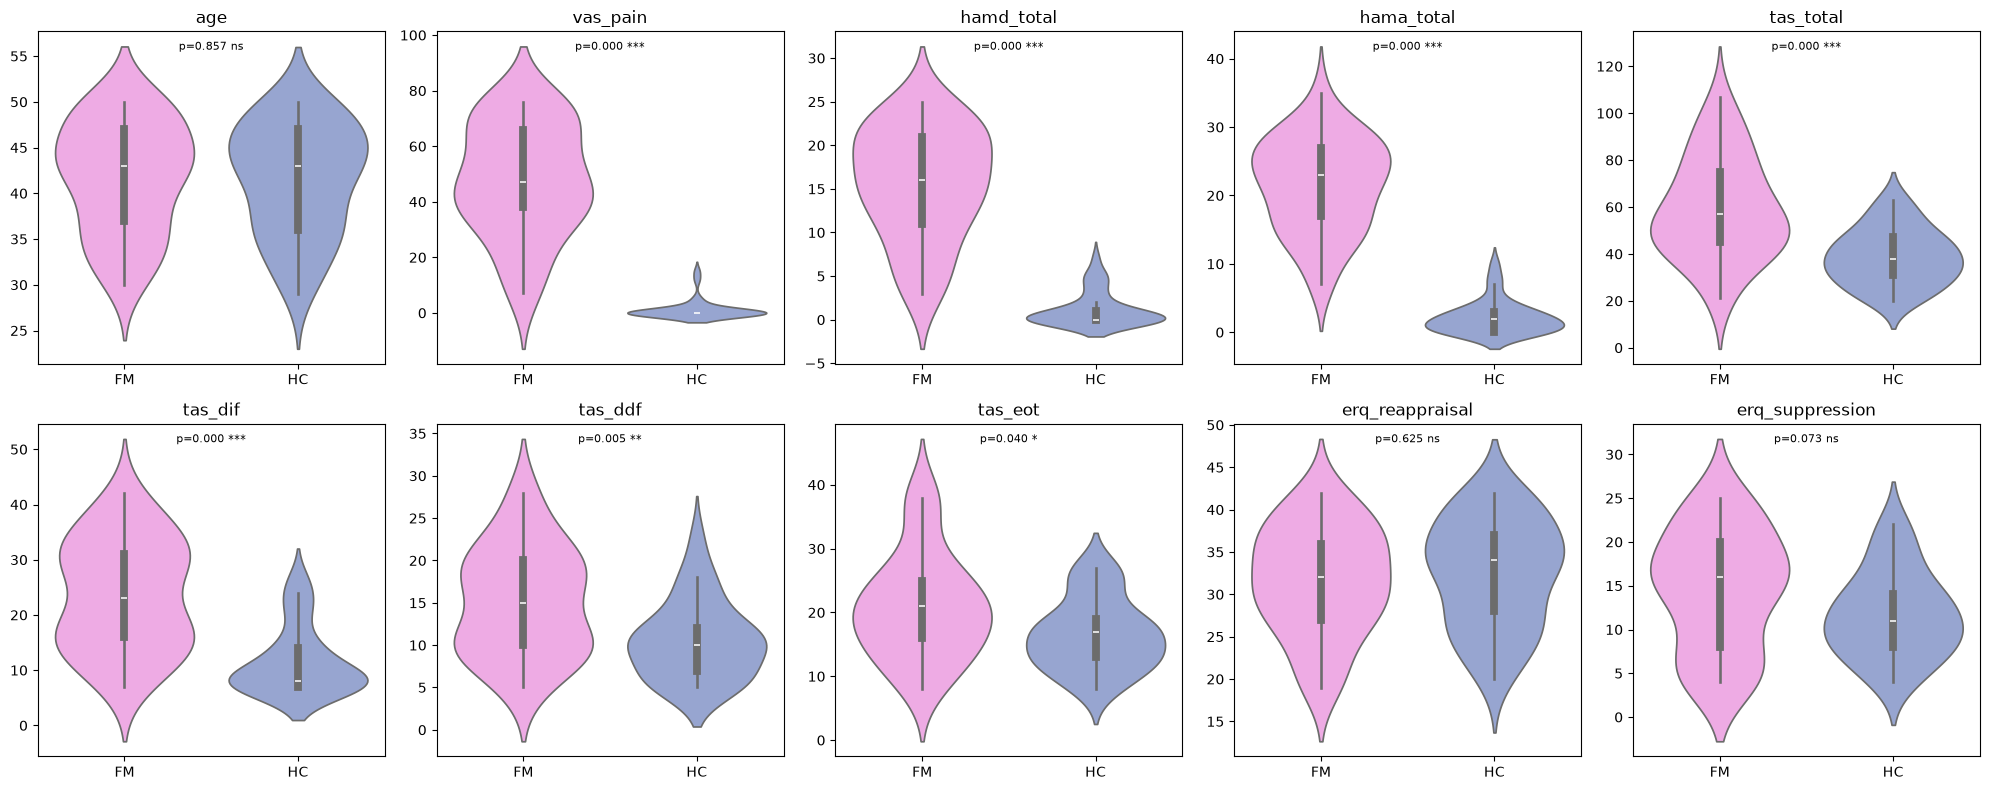

In [14]:
#the violin plot for each column
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes=axes.flatten()
k=0

for i in graph_cols:
    ax=axes[k]
    sns.violinplot(data=df_clean,x='group',y=graph_cols[k],palette={'FM': "#F9A0EC", 'HC': "#8EA0D9"},ax=ax)
    ax.set_title(i)
    ax.set_ylabel('')
    ax.set_xlabel('')
    p = p_values[i]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(0.5, 0.97, f'p={p:.3f} {sig}', transform=ax.transAxes, ha='center', va='top', fontsize=8)
    k+=1

plt.tight_layout()
plt.show()

In [15]:
#scaling bc the vars are on dif scales for radar plot
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
mpg=scaler.fit_transform(df_clean[graph_cols])
df_normal=pd.DataFrame(mpg,columns=graph_cols)
df_normal['group']=df_clean['group'].values
print(df_normal.head(5))

        age  vas_pain  hamd_total  hama_total  tas_total   tas_dif   tas_ddf  \
0  1.000000  0.960526        0.68    0.828571   0.850575  0.885714  0.695652   
1  0.666667  0.776316        0.56    0.571429   0.344828  0.400000  0.521739   
2  0.523810  0.907895        0.76    0.800000   0.586207  0.714286  0.391304   
3  0.619048  0.736842        0.84    0.600000   0.839080  0.800000  0.652174   
4  0.666667  0.000000        0.00    0.000000   0.275862  0.428571  0.173913   

    tas_eot  erq_reappraisal  erq_suppression group  
0  0.870968         0.521739         0.761905    FM  
1  0.129032         0.434783         0.476190    FM  
2  0.548387         0.391304         0.000000    FM  
3  0.967742         1.000000         0.952381    FM  
4  0.161290         0.565217         0.476190    HC  


In [16]:
#mean calc for acg clinical profile
means = df_normal.groupby('group')[graph_cols].mean()
print(means)

            age  vas_pain  hamd_total  hama_total  tas_total   tas_dif  \
group                                                                    
FM     0.606061  0.627592    0.623030    0.615584   0.455939  0.474459   
HC     0.595960  0.015550    0.048485    0.062338   0.217346  0.134199   

        tas_ddf   tas_eot  erq_reappraisal  erq_suppression  
group                                                        
FM     0.441370  0.416422         0.546772         0.502165  
HC     0.245059  0.276637         0.583663         0.369408  


In [17]:
fm_values = means.loc['FM'].values
hc_values = means.loc['HC'].values
angles = np.linspace(0, 2*np.pi, 10, endpoint=False)

print(fm_values)
print(hc_values)
print(angles)

[0.60606061 0.62759171 0.6230303  0.61558442 0.4559387  0.47445887
 0.44137022 0.41642229 0.54677207 0.5021645 ]
[0.5959596  0.01555024 0.04848485 0.06233766 0.21734587 0.13419913
 0.24505929 0.27663734 0.58366271 0.36940837]
[0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
 3.76991118 4.39822972 5.02654825 5.65486678]


In [18]:
fm_values = np.append(fm_values, fm_values[0])
hc_values = np.append(hc_values, hc_values[0])
angles = np.append(angles, angles[0])

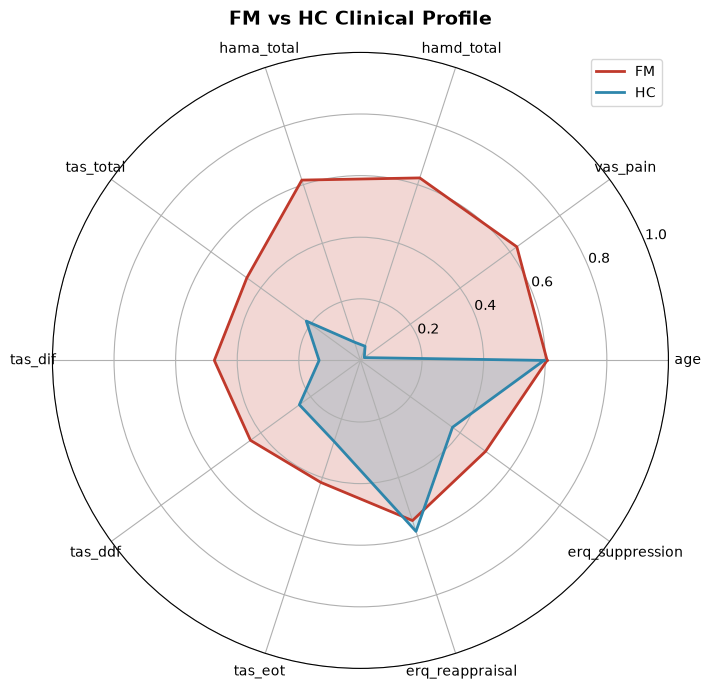

In [19]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, fm_values, color='#C0392B', linewidth=2, label='FM')
ax.fill(angles, fm_values, color='#C0392B', alpha=0.2)
ax.plot(angles, hc_values, color='#2E86AB', linewidth=2, label='HC')
ax.fill(angles, hc_values, color='#2E86AB', alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(graph_cols, size=10)
ax.set_ylim(0, 1)
ax.set_title('FM vs HC Clinical Profile', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right')
plt.show()

In [20]:
df_clean.to_csv('/Users/evangeline.bangsil/Desktop/DATA_clinical/clinical_clean.csv', index=False)